# Informe Teórico Práctico 2: Regresión Logística (Titanic)

SI3015 Fundamentos de Aprendizaje Automático, Universidad EAFIT, 2026

**Integrantes:** Julián Lara, Matías Martínez y Luis Alfonso Agudelo

**Dataset:** pasajeros del Titanic (`Titanic-Dataset.csv`)


Punto 1.2 del taller con el dataset del Titanic. El objetivo es predecir si un pasajero **sobrevivió** (`Survived`).

**Concepto: regresión logística.** Es un modelo de clasificación. Calcula $z = b_0 + b_1 x_1 + \dots + b_n x_n$ y lo pasa por la sigmoide $\sigma(z) = 1 / (1 + e^{-z})$ para obtener una probabilidad entre 0 y 1. Si la probabilidad supera 0.5 predice la clase positiva. Se usa para problemas binarios y permite ver, con el signo de cada coeficiente, si una variable sube o baja la probabilidad.

## 1. Carga del dataset

El archivo tiene 891 pasajeros y 12 columnas: identificador, si sobrevivió, clase del tiquete, nombre, sexo, edad, hermanos o pareja a bordo (`SibSp`), padres o hijos a bordo (`Parch`), número de tiquete, tarifa, cabina y puerto de embarque.

In [1]:
# Librerias que usamos en todo el notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
SEMILLA = 42  # semilla fija para que los resultados se puedan repetir

In [2]:
# El csv esta en la raiz del repositorio, un nivel arriba de esta carpeta
df_raw = pd.read_csv("../Titanic-Dataset.csv")
print("Filas y columnas:", df_raw.shape)
print("Filas duplicadas:", df_raw.duplicated().sum())
df_raw.head()

Filas y columnas: (891, 12)
Filas duplicadas: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Tipo de dato y faltantes por columna
pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "faltantes": df_raw.isna().sum(),
    "% faltantes": (df_raw.isna().mean() * 100).round(1),
})

,tipo,faltantes,% faltantes
PassengerId,int64,0,0.0
Survived,int64,0,0.0
Pclass,int64,0,0.0
Name,str,0,0.0
Sex,str,0,0.0
Age,float64,177,19.9
SibSp,int64,0,0.0
Parch,int64,0,0.0
Ticket,str,0,0.0
Fare,float64,0,0.0


## 2. Limpieza y transformación

Hay tres columnas con faltantes:

1. **Cabin** (77 % faltante). Imputar tanto no tiene sentido. Lo que sí se puede usar es el hecho de tener o no cabina registrada, que está muy ligado a la clase del pasajero. Creamos `tiene_cabina`.
2. **Age** (cerca del 20 % faltante). Rellenarla con la mediana general mezclaría niños con adultos. El nombre trae un título (`Mr`, `Mrs`, `Miss`, `Master`) que dice mucho de la edad: `Master` se usaba para niños y `Miss` para mujeres solteras, muchas de ellas jóvenes. Llenamos la edad con la mediana de cada título y guardamos una bandera `edad_faltante`.
3. **Embarked** (2 filas). Se llenan con el puerto más frecuente (Southampton).

Además creamos `tamano_familia` (`SibSp + Parch + 1`) y `viaja_solo`, pasamos `Sex` a 0/1 y el puerto y el título a one hot. `PassengerId`, `Name`, `Ticket` y `Cabin` no se usan directamente como entrada: el identificador no significa nada y los otros tres son texto casi único por persona.

In [4]:
def limpiar_titanic(df_raw):
    df = df_raw.copy()

    # Titulo que aparece en el nombre, entre la coma y el punto: "Braund, Mr. Owen Harris" da "Mr"
    df["titulo"] = df["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()
    df["titulo"] = df["titulo"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    comunes = ["Mr", "Mrs", "Miss", "Master"]
    df.loc[~df["titulo"].isin(comunes), "titulo"] = "Otro"

    # Edad faltante: mediana del mismo titulo y una bandera
    df["edad_faltante"] = df["Age"].isna().astype(int)
    df["Age"] = df["Age"].fillna(df.groupby("titulo")["Age"].transform("median"))

    # Puerto faltante: el mas frecuente
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    # Variables nuevas
    df["tiene_cabina"] = df["Cabin"].notna().astype(int)
    df["sexo"] = (df["Sex"] == "female").astype(int)  # 1 mujer, 0 hombre
    df["tamano_familia"] = df["SibSp"] + df["Parch"] + 1
    df["viaja_solo"] = (df["tamano_familia"] == 1).astype(int)
    df["log_tarifa"] = np.log1p(df["Fare"])

    # One hot de puerto y titulo
    dummies = pd.get_dummies(df[["Embarked", "titulo"]], prefix=["puerto", "titulo"], dtype=int)
    df = pd.concat([df, dummies], axis=1)
    return df


df = limpiar_titanic(df_raw)
cols_puerto = [c for c in df.columns if c.startswith("puerto_")]
cols_titulo = [c for c in df.columns if c.startswith("titulo_")]
print("Faltantes que quedan en las columnas usadas:", df[["Age", "Embarked", "Fare"]].isna().sum().sum())
df[["Survived", "Pclass", "sexo", "Age", "titulo", "tamano_familia", "Fare", "tiene_cabina", "Embarked"]].head(8)

Faltantes que quedan en las columnas usadas: 0


,Survived,Pclass,sexo,Age,titulo,tamano_familia,Fare,tiene_cabina,Embarked
0,0,3,0,22.0,Mr,2,7.2500,0,S
1,1,1,1,38.0,Mrs,2,71.2833,1,C
2,1,3,1,26.0,Miss,1,7.9250,0,S
3,1,1,1,35.0,Mrs,2,53.1000,1,S
4,0,3,0,35.0,Mr,1,8.0500,0,S
5,0,3,0,30.0,Mr,1,8.4583,0,Q
6,0,1,0,54.0,Mr,1,51.8625,1,S
7,0,3,0,2.0,Master,5,21.0750,0,S


## 3. Análisis exploratorio

In [5]:
def resumen_iqr(serie):
    # Rango intercuartilico, limites de outliers e IQR ratio como se vio en clase
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr, "lim_inf": lim_inf, "lim_sup": lim_sup,
        "outliers": int(((serie < lim_inf) | (serie > lim_sup)).sum()),
        "IQR_ratio": iqr / (serie.max() - serie.min()),
    })


df[["Age", "Fare", "log_tarifa", "SibSp", "Parch", "tamano_familia"]].apply(resumen_iqr).T.round(3)

,Q1,Q3,IQR,lim_inf,lim_sup,outliers,IQR_ratio
Age,21.000,35.000,14.000,0.000,56.000,35.0,0.176
Fare,7.910,31.000,23.090,-26.724,65.634,116.0,0.045
log_tarifa,2.187,3.466,1.279,0.269,5.384,31.0,0.205
SibSp,0.000,1.000,1.000,-1.500,2.500,46.0,0.125
Parch,0.000,0.000,0.000,0.000,0.000,213.0,0.000
tamano_familia,1.000,2.000,1.000,-0.500,3.500,91.0,0.100


Sobrevivio el 38.4 % de los pasajeros


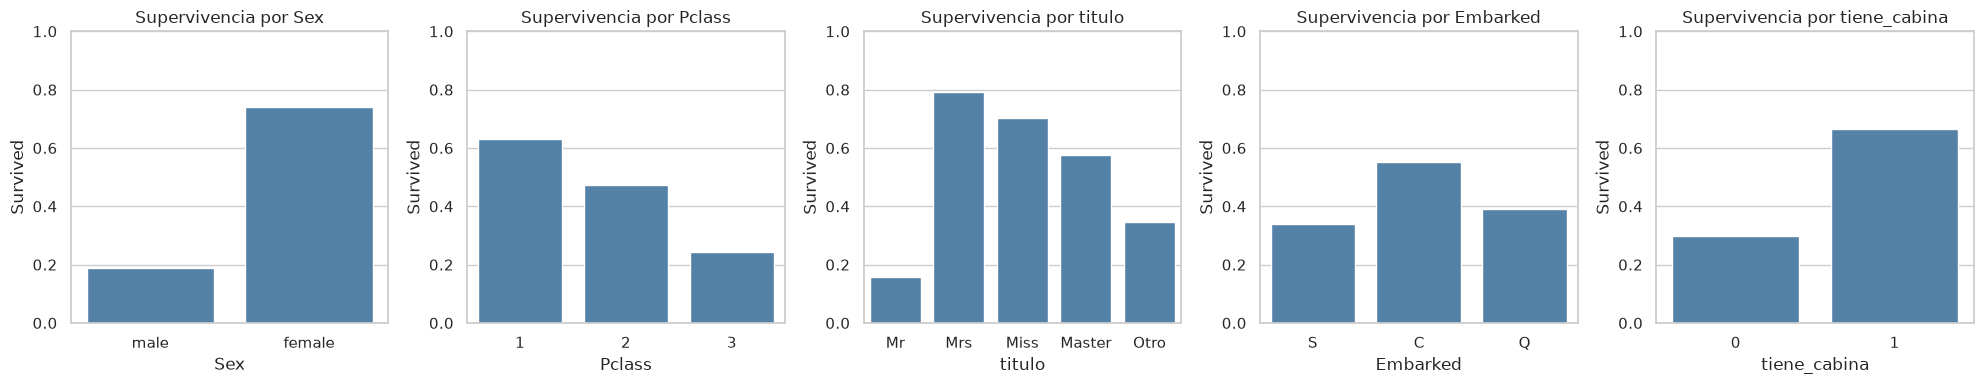

In [6]:
# Tasa de supervivencia general y segun las variables categoricas
print(f"Sobrevivio el {df['Survived'].mean() * 100:.1f} % de los pasajeros")
fig, ejes = plt.subplots(1, 5, figsize=(20, 4))
for eje, col in zip(ejes, ["Sex", "Pclass", "titulo", "Embarked", "tiene_cabina"]):
    sns.barplot(data=df, x=col, y="Survived", ax=eje, errorbar=None, color="steelblue")
    eje.set_title(f"Supervivencia por {col}")
    eje.set_ylim(0, 1)
plt.tight_layout()
plt.show()

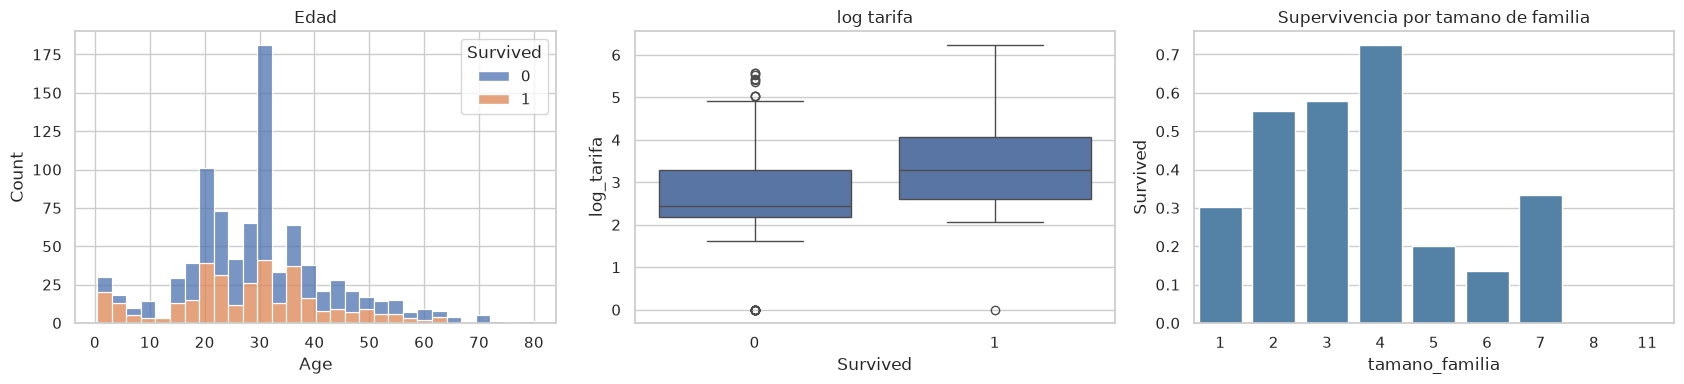

In [7]:
fig, ejes = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(data=df, x="Age", hue="Survived", bins=30, multiple="stack", ax=ejes[0]).set_title("Edad")
sns.boxplot(data=df, x="Survived", y="log_tarifa", ax=ejes[1]).set_title("log tarifa")
sns.barplot(data=df, x="tamano_familia", y="Survived", errorbar=None, ax=ejes[2], color="steelblue")
ejes[2].set_title("Supervivencia por tamano de familia")
plt.tight_layout()
plt.show()

Lo que sacamos del análisis exploratorio:

1. Sobrevivió el 38.4 % de los pasajeros. Las clases están algo desbalanceadas, pero no tanto como para necesitar técnicas de balanceo.
2. El sexo es la variable más fuerte: sobrevivió el 74.2 % de las mujeres y solo el 18.9 % de los hombres (la regla de "mujeres y niños primero").
3. La clase también pesa: 63 % de supervivencia en primera, 47.3 % en segunda y 24.2 % en tercera.
4. El título resume sexo y edad: `Mrs` 79.4 %, `Miss` 70.3 %, `Master` (niños) 57.5 % y `Mr` apenas 15.7 %.
5. Tener cabina registrada duplica la tasa de supervivencia (66.7 % contra 30 %), y quienes embarcaron en Cherbourg sobrevivieron más, porque ahí subieron muchos pasajeros de primera clase.
6. Con el tamaño de familia la relación no es lineal: los que viajaban solos sobrevivieron un 30 %, las familias de 2 a 4 personas entre 55 % y 72 %, y las familias de 5 o más muy poco.

### División, escalado y métricas

Separamos 80 % para entrenar y 20 % para probar, **estratificando** por `Survived` para que los dos conjuntos tengan la misma proporción de sobrevivientes.

Usamos `StandardScaler` dentro de un `Pipeline` porque la regresión logística de scikit learn aplica regularización, y sin escalar la tarifa (hasta 512) quedaría castigada distinto que una variable 0/1. El pipeline calcula la media y la desviación solo con el entrenamiento.

Las métricas son: **matriz de confusión**, **accuracy** (aciertos totales), **precision** ($VP / (VP + FP)$: de los que el modelo dijo que sobrevivieron, cuántos sí), **recall** ($VP / (VP + FN)$: de los que sobrevivieron, cuántos encontró) y **F1** (media armónica de precision y recall).

In [8]:
train, test = train_test_split(df, test_size=0.2, random_state=SEMILLA, stratify=df["Survived"])
print("Entrenamiento:", len(train), "| Prueba:", len(test))
print(f"Accuracy prediciendo siempre 'no sobrevivio': {(test['Survived'] == 0).mean():.3f}")


def evaluar_clasificador(columnas, nombre, mostrar=True):
    modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    modelo.fit(train[columnas], train["Survived"])
    pred = modelo.predict(test[columnas])
    met = {
        "modelo": nombre,
        "n_variables": len(columnas),
        "accuracy_train": accuracy_score(train["Survived"], modelo.predict(train[columnas])),
        "accuracy": accuracy_score(test["Survived"], pred),
        "precision": precision_score(test["Survived"], pred),
        "recall": recall_score(test["Survived"], pred),
        "f1": f1_score(test["Survived"], pred),
    }
    if mostrar:
        fig, eje = plt.subplots(figsize=(4.5, 4))
        ConfusionMatrixDisplay(confusion_matrix(test["Survived"], pred), display_labels=["murio", "sobrevivio"]).plot(
            ax=eje, cmap="Blues", colorbar=False)
        eje.set_title(nombre)
        plt.show()
        print(classification_report(test["Survived"], pred, target_names=["murio", "sobrevivio"], digits=3))
    return modelo, pred, met

Entrenamiento: 712 | Prueba: 179
Accuracy prediciendo siempre 'no sobrevivio': 0.615


## 4. Caso 1: regresión logística con una variable

**Enunciado.** Seleccionar una única columna característica y una variable objetivo, obtener matriz de confusión, accuracy, f1 score, precision y recall y sacar conclusiones.

**Objetivo:** `Survived`. **Característica:** `sexo`, la que más separa las clases en el análisis exploratorio.

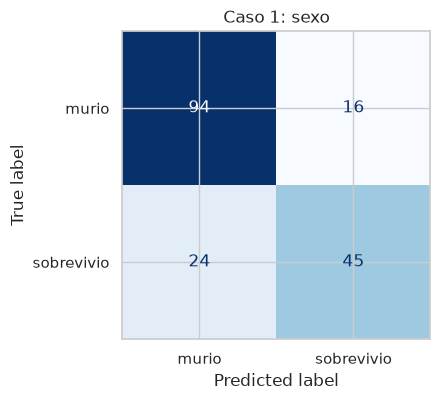

              precision    recall  f1-score   support

       murio      0.797     0.855     0.825       110
  sobrevivio      0.738     0.652     0.692        69

    accuracy                          0.777       179
   macro avg      0.767     0.753     0.758       179
weighted avg      0.774     0.777     0.774       179



,modelo,n_variables,accuracy_train,accuracy,precision,recall,f1
0,Caso 1: sexo,1,0.7893,0.7765,0.7377,0.6522,0.6923


In [9]:
modelo_1, pred_1, met_1 = evaluar_clasificador(["sexo"], "Caso 1: sexo")
pd.DataFrame([met_1]).round(4)

### Conclusiones del caso 1

Con solo el sexo el modelo llega a un accuracy de 0.777, contra 0.615 de decir siempre que el pasajero murió. En la práctica aprende la regla "mujer sobrevive, hombre muere". De los 110 que murieron acierta 94, y de los 69 que sobrevivieron acierta 45 (recall de 0.652). Los errores son justamente los hombres que sobrevivieron y las mujeres que murieron. Casi todas esas mujeres viajaban en tercera clase.

El F1 de la clase positiva es 0.692. El accuracy de entrenamiento (0.789) y el de prueba (0.777) son casi iguales. Con una variable binaria el modelo no tiene cómo sobreajustar.

## 5. Caso 2: regresión logística con varias variables

**Enunciado.** Seleccionar dos columnas características, obtener las mismas métricas y agregar las columnas necesarias para mejorarlas.

Empezamos con `sexo` y `Pclass`. Después agregamos edad, luego familia y tarifa, y al final título, puerto y cabina.

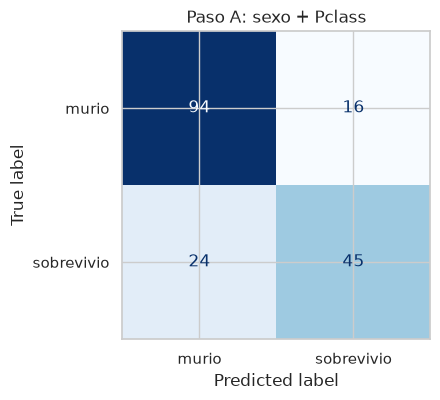

              precision    recall  f1-score   support

       murio      0.797     0.855     0.825       110
  sobrevivio      0.738     0.652     0.692        69

    accuracy                          0.777       179
   macro avg      0.767     0.753     0.758       179
weighted avg      0.774     0.777     0.774       179



In [10]:
modelo_a, pred_a, met_a = evaluar_clasificador(["sexo", "Pclass"], "Paso A: sexo + Pclass")

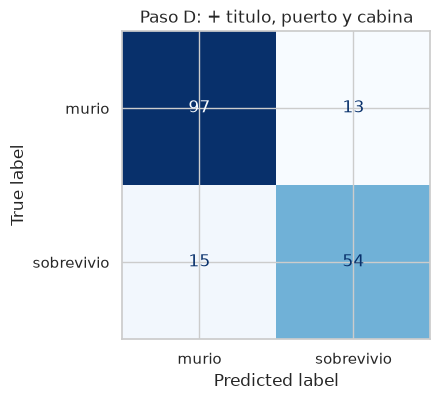

              precision    recall  f1-score   support

       murio      0.866     0.882     0.874       110
  sobrevivio      0.806     0.783     0.794        69

    accuracy                          0.844       179
   macro avg      0.836     0.832     0.834       179
weighted avg      0.843     0.844     0.843       179



,n_variables,accuracy_train,accuracy,precision,recall,f1
modelo,,,,,,
Caso 1: sexo,1,0.7893,0.7765,0.7377,0.6522,0.6923
Paso A: sexo + Pclass,2,0.7893,0.7765,0.7377,0.6522,0.6923
Paso B: + edad,4,0.7978,0.7821,0.7419,0.6667,0.7023
Paso C: + familia y tarifa,7,0.7992,0.8212,0.7846,0.7391,0.7612
"Paso D: + titulo, puerto y cabina",18,0.8329,0.8436,0.8060,0.7826,0.7941


In [11]:
pasos = {
    "Paso B: + edad": ["sexo", "Pclass", "Age", "edad_faltante"],
    "Paso C: + familia y tarifa": ["sexo", "Pclass", "Age", "edad_faltante", "tamano_familia", "viaja_solo", "log_tarifa"],
}
resultados = [met_1, met_a]
for nombre, columnas in pasos.items():
    resultados.append(evaluar_clasificador(columnas, nombre, mostrar=False)[2])

todas = pasos["Paso C: + familia y tarifa"] + ["SibSp", "Parch", "tiene_cabina"] + cols_puerto + cols_titulo
modelo_d, pred_d, met_d = evaluar_clasificador(todas, "Paso D: + titulo, puerto y cabina")
resultados.append(met_d)
tabla = pd.DataFrame(resultados).set_index("modelo").round(4)
tabla

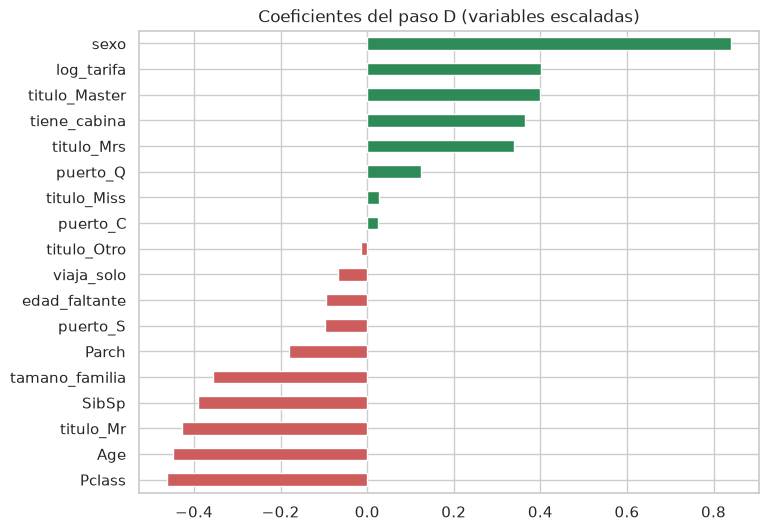

In [12]:
coef = pd.Series(modelo_d.named_steps["logisticregression"].coef_[0], index=todas).sort_values()
coef.plot(kind="barh", figsize=(8, 6), color=np.where(coef > 0, "seagreen", "indianred"))
plt.title("Coeficientes del paso D (variables escaladas)")
plt.show()

### Conclusiones del caso 2

Al agregar `Pclass` (paso A) las métricas **no cambian**. La razón está en el análisis exploratorio: las mujeres de primera y segunda clase sobrevivieron más del 90 % de las veces, pero las de tercera solo el 50 %, y los hombres mueren en su mayoría en todas las clases. La clase cambia la probabilidad, pero no lo suficiente para cruzar el umbral de 0.5 en ningún grupo, así que las predicciones finales siguen siendo las mismas.

La edad (paso B) sube un poco el accuracy a 0.782 porque permite rescatar a algunos niños. El salto grande viene con la familia y la tarifa (paso C, 0.821). Con el título, el puerto y la cabina (paso D) el modelo llega a un accuracy de **0.844** y un F1 de **0.794**, con precision de 0.806 y recall de 0.783.

Entre los coeficientes del modelo final, el sexo es por lejos el más grande (ser mujer sube la probabilidad de sobrevivir). Después vienen la tarifa, el título `Master`, tener cabina y el título `Mrs` del lado positivo, y la clase, la edad, el título `Mr` y el número de hermanos o pareja a bordo del lado negativo. El accuracy de entrenamiento (0.833) y el de prueba (0.844) siguen muy cerca, así que el modelo generaliza bien.

## 6. Conclusiones generales

1. El sexo por sí solo explica gran parte de la supervivencia (accuracy de 0.777), y con todas las variables limpias se llega a 0.844.
2. Una variable importante no siempre cambia las predicciones. La clase no movió ninguna métrica en el paso A porque no alcanzaba a cruzar el umbral de decisión en ningún grupo.
3. Las variables construidas en la limpieza (título, tamaño de familia, tener cabina) fueron las que más mejoraron el modelo.